# Data Pre-Processing

#### Import Packages and CSV

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"Graduate.csv")
# Print shape of dataset
print(df.shape)

(1000, 17)


## Data Cleaning

### Handling Missing values

* Handling Missing values 
* Handling Duplicates
* Check data type
* Understand the dataset

#### Check Null Values

In [113]:
##these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

In [114]:
features_with_na

[]

* **There are no null values in the dataset**

### 3.2 Other Data Cleaning steps

**Handling Duplicates**

In [115]:
df.duplicated().sum()

0

* **No Duplicates in the dataset**

**Drop useless features identified during EDA (Country and Target_Program) as they add noise**


In [116]:
df.drop(['Country', 'Target_Program'], inplace=True, axis=1)


# Feature Engineering

## Feature Extraction

In [117]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Graduation_Year,Scholarship_Awarded
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,2024,No
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,2025,No
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,2022,No
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,2025,No
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,2025,No


In [118]:
# importing date class from datetime module
from datetime import date
  
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [119]:
current_year = 2025


**Subtract Graduation Year from the base year (2025) to get Years Since Graduation**


In [120]:
df['Years_Since_Graduation'] = current_year - df['Graduation_Year']


In [121]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Graduation_Year,Scholarship_Awarded,Years_Since_Graduation
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,2024,No,1
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,2025,No,0
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,2022,No,3
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,2025,No,0
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,2025,No,0


In [122]:
df.drop('Graduation_Year', inplace=True, axis=1)


### Type of Features

**Numeric Features**

In [123]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 13


**Categorical Features**

In [124]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 2


**Discrete features**

In [125]:
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 7


**Continues Features**

In [126]:
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 6


### Split X and Y

* **Split Dataframe to X and y**
* **Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the “Scholarship_Awarded” column.**


In [127]:
X = df.drop('Scholarship_Awarded', axis=1)
y = df['Scholarship_Awarded']


In [128]:
y.head()

0    No
1    No
2    No
3    No
4    No
Name: Scholarship_Awarded, dtype: object

**Manual encoding target column (Scholarship_Awarded)**


In [129]:
# If the target column has Yes it is encoded as 1 others as 0
y= np.where(y=='Yes', 1,0)


In [130]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,

## Feature Transformation

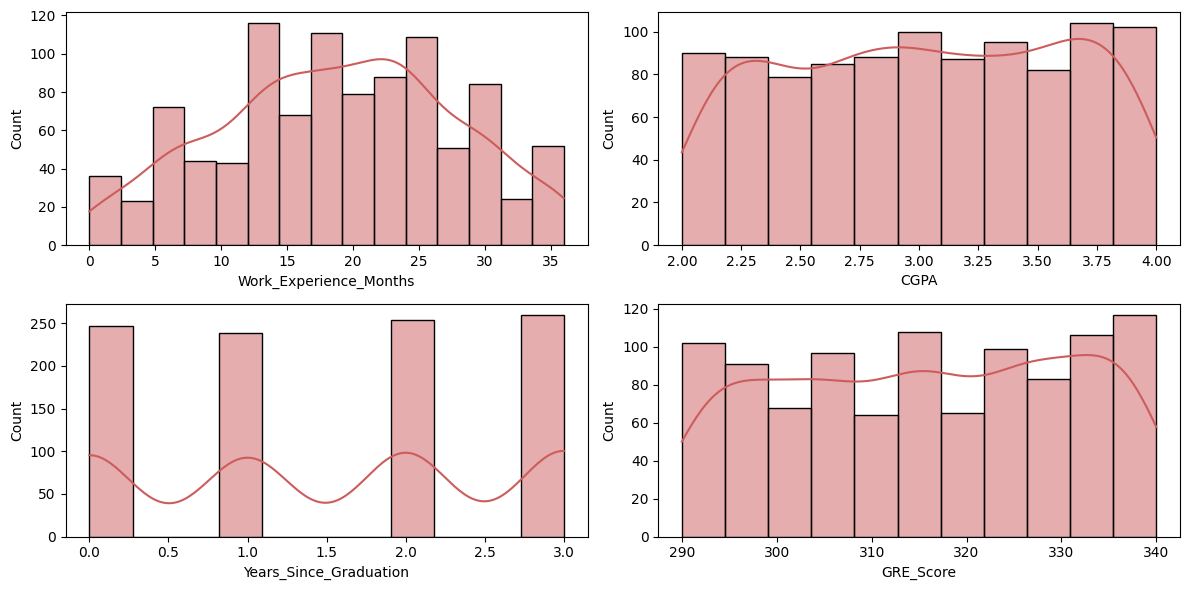

In [131]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
# Swapped the tutorial columns with our continuous features!
for i, col in enumerate(['Work_Experience_Months', 'CGPA', 'Years_Since_Graduation', 'GRE_Score']):
    plt.subplot(2, 2, i+1)
    # Added kde=True so you can easily see the skewness curve
    sns.histplot(x=X[col], color='indianred', kde=True) 
    plt.xlabel(col)
    plt.tight_layout()


* Work_Experience_Months and Years_Since_Graduation columns are skewed
* Apply a power transform feature to make it more Gaussian-like.


**Checking Skewness**

**What is Skewness ?**

* Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [132]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

GRE_Score                -0.076986
TOEFL_Score              -0.043179
CGPA                     -0.049968
SOP                      -0.001144
LOR                       0.017292
Work_Experience_Months   -0.083608
dtype: float64

- Positiviely Skewed : Work_Experience_Months, Years_Since_Graduation.
- We can handle outliers and then apply Power Transformer on these columns.


## Apply Power Transformer to Check if it can reduces the outliers

In [133]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['Work_Experience_Months', 'Years_Since_Graduation']
X_copy = pt.fit_transform(X[transform_features])


In [134]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

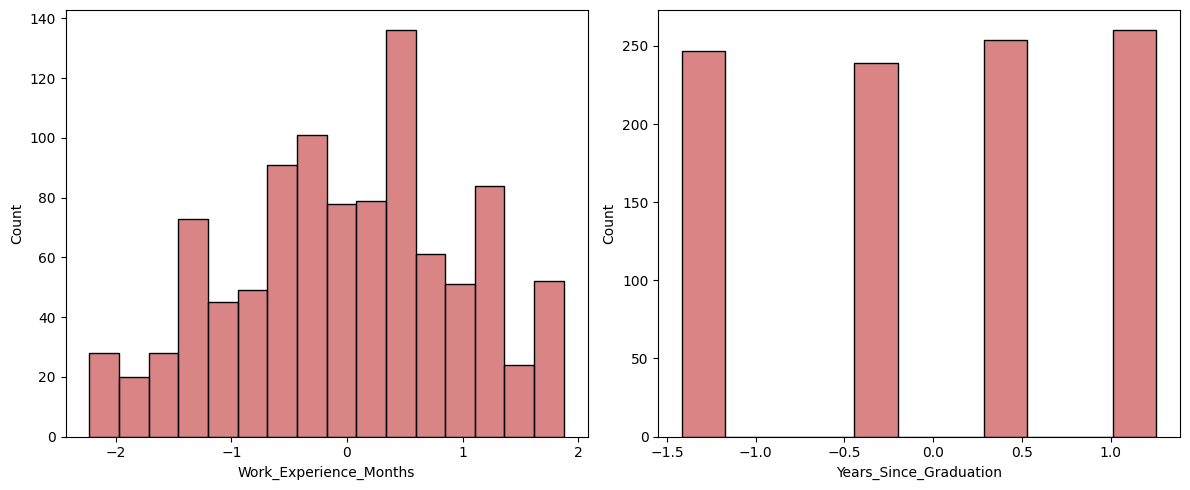

In [135]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

**Checking Skewness**

In [136]:
X_copy.skew(axis=0, skipna=True)

Work_Experience_Months   -0.175719
Years_Since_Graduation   -0.175311
dtype: float64

- Here Yeo-Johnson is used and it supports both positive or negative data for transformation.
- So Power Transformer with yeo-johnson can be used.

In [137]:
for feature in cat_features:
    print(feature,':', df[feature].nunique())

Internship : 2
Scholarship_Awarded : 2


## Feature Encoding and Scaling

 **One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Ordinal Encoding for Columns which has many unique categories** 
* Ordinal encoding is used here as label encoder is supported for column transformer.
* Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

**Standard Scaler** 
* Standardize features by removing the mean and scaling to unit variance.

**Power Transformer**
* Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

**Selecting number features for preprocessing**

In [138]:
num_features = list(X.select_dtypes(exclude="object").columns)

In [139]:
num_features

['GRE_Score',
 'TOEFL_Score',
 'IELTS_Score',
 'CGPA',
 'University_Rating',
 'SOP',
 'LOR',
 'Research',
 'Publications',
 'Work_Experience_Months',
 'Leadership_Score',
 'Awards_Count',
 'Years_Since_Graduation']

### **Preprocessing using Column Transformer**

In [140]:
# Create Column Transformer with 3 types of transformers
or_columns = []
oh_columns = ['Research', 'Internship']
transform_columns = ['Work_Experience_Months', 'Years_Since_Graduation']
# Remove transform columns from num_features to avoid redundancy
num_features = [col for col in num_features if col not in transform_columns]

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


In [141]:
X = preprocessor.fit_transform(X)

In [142]:
X

array([[ 1.        ,  0.        ,  1.        , ..., -0.13102747,
         0.3227036 , -0.70029881],
       [ 1.        ,  0.        ,  0.        , ..., -0.13102747,
        -0.39761693, -0.70029881],
       [ 0.        ,  1.        ,  0.        , ...,  0.97004373,
        -0.39761693,  1.40270062],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.13102747,
         0.3227036 , -0.70029881],
       [ 1.        ,  0.        ,  0.        , ..., -1.23209868,
         0.3227036 , -0.70029881],
       [ 0.        ,  1.        ,  0.        , ...,  0.97004373,
        -1.83825798,  1.40270062]])

# Classification

In [143]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek, SMOTEENN

# 1. SPLIT FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. RESAMPLE ONLY THE TRAINING DATA
smt = SMOTEENN(random_state=42, sampling_strategy='minority')
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)


## Train Test Split
- The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

- It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms.

In [144]:
# Data is already split and resampled above.
print(f"Resampled Training Set: {X_train_res.shape}")
print(f"Test Set: {X_test.shape}")


Resampled Training Set: (1027, 17)
Test Set: (200, 17)


In [145]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [146]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [147]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [148]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X_train, X_test, y_train, y_test, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    
    models_list = []
    accuracy_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report

## Model Training 

In [149]:
base_model_report = evaluate_models(X_train_res, X_test, y_train_res, y_test, models=models)


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8550
- F1 score: 0.7883
- Precision: 0.6750
- Recall: 0.9474
- Roc Auc Score: 0.8828


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8250
- F1 score: 0.7368
- Precision: 0.6447
- Recall: 0.8596
- Roc Auc Score: 0.8354


Gradient Boosting
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8550
- F1 score: 0.7883
- Precision: 0.6750
- Recall: 0.9474
- Roc Auc Score: 0.8828


Logistic Regression
Model performance for Training 

**Results of All Models**

In [150]:
base_model_report

,Model Name,Accuracy
8,AdaBoost Classifier,0.885
3,Logistic Regression,0.875
5,XGBClassifier,0.875
7,Support Vector Classifier,0.875
6,CatBoosting Classifier,0.865
0,Random Forest,0.855
2,Gradient Boosting,0.855
4,K-Neighbors Classifier,0.835
1,Decision Tree,0.825


**Here we can use Random Forest for Hyper Parameter Tuning**

**Define the parameter distribution for Random forest**

In [151]:
#Initialize few parameter for Hyperparamter tuning
xgboost_params = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}

knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree','brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9],
}

In [152]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

**Create a function for model training and report which can be used in hyperparameter tuning loop**

In [153]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2, 
                                   n_jobs=-1)
    random.fit(X_train_res, y_train_res)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'min_child_weight': 1, 'max_depth': 3}
---------------- Best Params for RF -------------------
{'n_estimators': 10, 'max_features': 'sqrt', 'max_depth': 15}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [154]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 3},
 'RF': {'n_estimators': 10, 'max_features': 'sqrt', 'max_depth': 15},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

## Retraining the Model with best Parameters

In [155]:
from sklearn.metrics import roc_auc_score,roc_curve
best_models = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'],n_jobs=-1),
}
tuned_report = evaluate_models(X_train_res, X_test, y_train_res, y_test, models=best_models)


Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8650
- F1 score: 0.8000
- Precision: 0.6923
- Recall: 0.9474
- Roc Auc Score: 0.8898


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8550
- F1 score: 0.7914
- Precision: 0.6707
- Recall: 0.9649
- Roc Auc Score: 0.8881


XGBClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8750
- F1 score: 0.8062
- Precision: 0.7222
- Recall: 0.9123
- Roc Auc Score: 0.8862




In [156]:
tuned_report

,Model Name,Accuracy
2,XGBClassifier,0.875
0,Random Forest Classifier,0.865
1,KNeighborsClassifier,0.855


In [157]:
best_model_name = tuned_report.iloc[0]['Model Name']
best_model = best_models[best_model_name]
best_model = best_model.fit(X_train_res, y_train_res)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print(f"FINAL MODEL '{best_model_name}'")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)


FINAL MODEL 'XGBClassifier'
Accuracy Score value: 0.8750
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       143
           1       0.72      0.91      0.81        57

    accuracy                           0.88       200
   macro avg       0.84      0.89      0.86       200
weighted avg       0.89      0.88      0.88       200



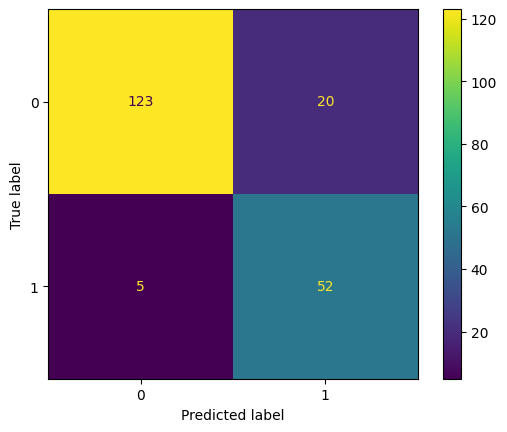

In [158]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## Final Model Evaluation
*(The best model is now chosen automatically based on the tuned_report dataframe above)*

In [159]:
best_model_name = tuned_report.iloc[0]['Model Name']
best_model = best_models[best_model_name]
